### Downstream analysis RMI & RPI indexes, module: metal_indexes_rb
Raw reads count are aggregated for all the samples using the geomosaic command:
```bash
geomosaic gather -s gmsetup -p redox_metal_plasticity_index
```

plot of the variation in the Redox Metabolic Index (A) and the Metal Plasticity Index (B) against temperature for a series of metagenomes obtained using the read-based analysis stream.

In [2]:
# Imports
library(phyloseq)
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(vegan)
library(ggrepel)
library(patchwork)
library(ggpubr)    # per stat_compare_means e stat_pvalue_manual
library(rstatix)   # per dunn_test
options(readr.show_col_types = FALSE)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: permute


Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter




In [3]:
theme_glab <- function(base_size = 11, base_family = "") {
  theme_bw(base_size = base_size, base_family = base_family) %+replace%
    theme(
      legend.background = element_blank(),
      legend.title      = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65),
        hjust = 0
      ),
      legend.text       = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      legend.key.size   = unit(0.8, "lines"),
      plot.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        hjust = 0.5, 
        face = "bold"
      ),
      axis.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      axis.text         = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      panel.grid.major  = element_blank(),
      panel.grid.minor  = element_blank(),
      panel.border      = element_rect(
        fill = NA,
        colour = rgb(100, 100, 100, maxColorValue = 255)
      ),
      complete = TRUE
    )
}

In [4]:
env <- as.data.frame(read_delim("../table_mars/cr18_env_geomosaicPlot.csv", 
                  delim = ",",
                  skip = 1, 
                  locale = locale(decimal_mark = ",")))

rownames(env) <- env$Geomosaic_sample


In [5]:
plot_scatter <- function(df, x_col, y_col, color_col,label_col) {
  # We use x_col and y_col as strings (e.g., "rmi")
  ggplot(df, aes(x = .data[[x_col]], 
                 y = .data[[y_col]],
                 color = .data[[color_col]], # This adds the F/S coloring
                 label = .data[[label_col]])) +
    geom_point(size = 3) +
    geom_text_repel(size = 3, show.legend = FALSE) + # hide 'a' from legend
    labs(
      x = x_col,
      y = y_col,
      color = color_col,
      title = paste("Scatterplot:", x_col, "vs", y_col)
    ) +
    theme_glab() +
    # Optional: ensure F and S have distinct, clean colors
    scale_color_brewer(palette = "Set1") 
}


In [6]:
# --- 1. Sample-to-category assignment (edit this as needed) ---

dt <- data.frame(
  sample = c("SRR38179882","SRR38781006","SRR37709773","SRR3963449","ERR1877670","ERR1877774","ERR1877776","SRR38179869","SRR38179880","ERR599017","ERR599116","ERR599146","ERR599132","ERR1877661","CR18_LE180416_F","CR18_LE180416_S","CR18_ER180415_F","CR18_ER180415_S","SRR38179866","ERR599070","ERR1877791","ERR1877778","CR18_LB180410_F","CR18_LB180410_S"),
  biome = c("host-associated","host-associated","host-associated","seawater","soil","soil","soil","host-associated","host-associated","seawater","seawater","seawater","seawater","soil","subsurface","subsurface","subsurface","subsurface","host-associated","seawater","soil","soil","subsurface","subsurface")
)

In [7]:
write.csv(dt, "../tables/sample_biome_mapping.csv", row.names = FALSE)

In [8]:
# index_data should have columns: samples, redox_metabolic_index, metal_plasticty_index
index_data <- read.delim("../tables/gm_gathering/redox_metal_plasticity_index/redox_metal_indexes.tsv", header = TRUE, sep = "\t")

# Merge category info with index data
merged <- merge(dt, index_data, by = "sample")

merged

sample,biome,redox_metabolic_index,metal_plasticity_index,acceptors_metals,donors_metal,acceptor_substrates,donor_substrates,metal_dex
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
CR18_ER180415_F,subsurface,5.0499,3.7612,Cu;Fe;Ln;Mg;Mo;Ni;NiCu,Cu;CuMo;Fe;Mo;MoCo;Ni;W,Ammonia/Methane;Arsenate;CO2;DMSO;Lactate;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Ammonia/Methane;Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Sulfur;Thiosulfate;Water,NA
CR18_ER180415_S,subsurface,4.9628,3.5835,Cu;Fe;Ln;Mo;Ni;NiCu,Cu;CuMo;Fe;Mo;MoCo;Ni;W,Ammonia/Methane;Arsenate;CO2;DMSO;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Ammonia/Methane;Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Sulfur;Thiosulfate;Water,NA
CR18_LB180410_F,subsurface,5.2040,3.8918,"['W', 'Cu', 'Ni', 'CuMo', 'Fe', 'MoCo', 'Mo']","['W', 'Cu', 'Ni', 'CuMo', 'Fe', 'MoCo', 'Mo']","['Nitric oxide', 'Ammonia/Methane', 'Nitrite', 'Lactate', 'Nitrate', 'Sulfate', 'Nitrous oxide', 'Methanol', 'Arsenate', 'Oxygen', 'CO2', 'DMSO', 'Sulfite']","['Water', 'Hydrogen/CO2', 'Nitrite', 'Ammonia/Methane', 'CO', 'Sulfide', 'Sulfur', 'DMS', 'Hydroxylamine', 'Hydrogen', 'Thiosulfate', 'Arsenite', 'Organic carbon', 'Sulfite']",NA
CR18_LB180410_S,subsurface,5.1240,3.8918,"['Cu', 'Fe', 'W', 'CuMo', 'MoCo', 'Mo', 'Ni']","['Cu', 'Fe', 'W', 'CuMo', 'MoCo', 'Mo', 'Ni']","['Nitric oxide', 'Nitrite', 'Nitrous oxide', 'Oxygen', 'CO2', 'Ammonia/Methane', 'DMSO', 'Nitrate', 'Arsenate', 'Methanol', 'Sulfate', 'Lactate']","['DMS', 'Nitrite', 'Hydrogen/CO2', 'Sulfide', 'Arsenite', 'Sulfite', 'Ammonia/Methane', 'Thiosulfate', 'Sulfur', 'Water', 'Organic carbon', 'CO', 'Hydroxylamine', 'Hydrogen']",NA
CR18_LE180416_F,subsurface,5.1299,3.7612,Cu;Fe;Ln;Mg;Mo;Ni;NiCu,Cu;CuMo;Fe;Mo;MoCo;Ni;W,Ammonia/Methane;Arsenate;CO2;DMSO;Hydrazine;Lactate;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Ammonia/Methane;Arsenite;CO;Hydrazine;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Sulfur;Thiosulfate,NA
CR18_LE180416_S,subsurface,5.1299,3.5835,Cu;Fe;Ln;Mo;Ni;NiCu,Cu;CuMo;Fe;Mo;MoCo;Ni;W,Ammonia/Methane;Arsenate;CO2;DMSO;Hydrazine;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate;Sulfite,Ammonia/Methane;Arsenite;CO;Hydrazine;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Sulfur;Thiosulfate,NA
ERR1877661,soil,3.9120,2.8904,Cu;Fe;Ln,CuMo;Fe;Mo;MoCo;Ni;W,Methanol;Nitrate;Nitrite;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Nitrite;Organic carbon;Sulfide;Sulfite;Sulfur;Thiosulfate,2.8904
ERR1877670,soil,4.4773,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfide;Sulfite;Sulfur;Thiosulfate,NA
ERR1877774,soil,4.4998,3.4965,Cu;Fe;Ln;Mo;Ni;NiCu,CuMo;Fe;Mo;MoCo;Ni;W,Arsenate;CO2;Methanol;Nitrate;Nitric oxide;Nitrite;Nitrous oxide;Oxygen;Sulfate,Arsenite;CO;Hydrogen;Hydrogen/CO2;Hydroxylamine;Nitrite;Organic carbon;Sulfite;Sulfur;Thiosulfate,NA


In [10]:
# Redox metabolic index
kw1 <- merged %>% kruskal_test(redox_metabolic_index ~ biome)
dunn1 <- merged %>%
  dunn_test(redox_metabolic_index ~ biome, p.adjust.method = "BH") %>%
  add_xy_position(x = "biome")


# Metal plasticity index
kw2 <- merged %>% kruskal_test(metal_plasticity_index ~ biome)
dunn2 <- merged %>%
  dunn_test(metal_plasticity_index ~ biome, p.adjust.method = "BH") %>%
  add_xy_position(x = "biome")

# --- Rimuovi la colonna 'groups' (list-column) prima di esportare ---
dunn1_export <- dunn1 %>% select(-groups)
dunn2_export <- dunn2 %>% select(-groups)

write.csv(kw1, "./table_kw1.csv", row.names = FALSE)
write.csv(dunn1_export, "./table_dunn1.csv", row.names = FALSE)
write.csv(kw2, "./table_kw2.csv", row.names = FALSE)
write.csv(dunn2_export, "./table_dunn2.csv", row.names = FALSE)

write.csv(merged,"./table_merged.csv", row.names = FALSE)

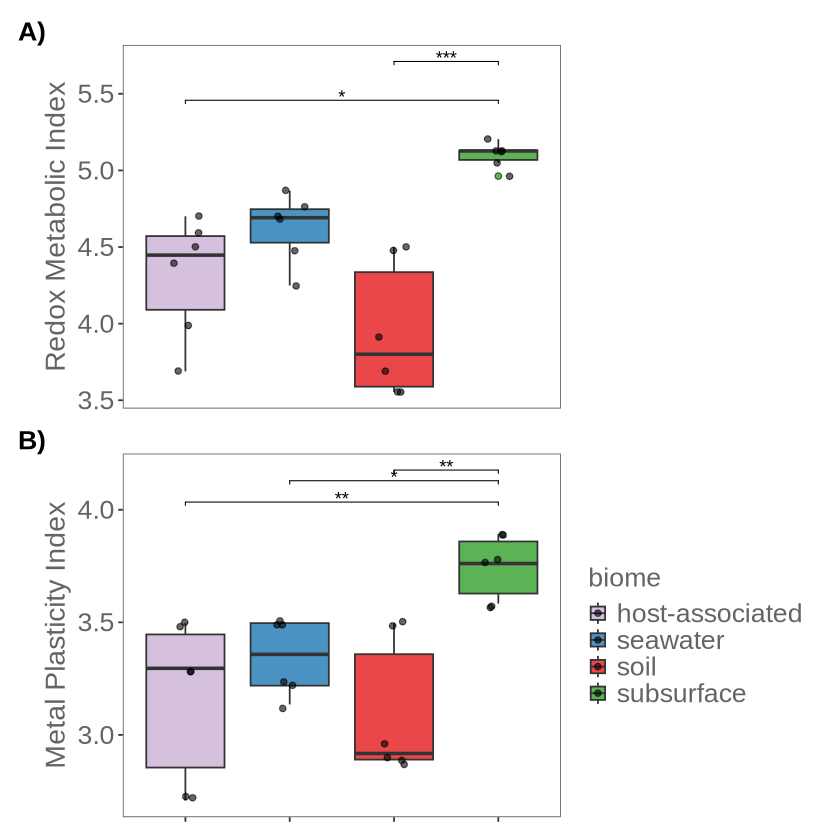

In [12]:
biome_colors <- c(
"#cab2d6",
"#1F78B4",  # blu
"#e31a1c",
"#33a02c"  # verde
)



# --- 4. Boxplot for redox_metabolic_index (RMI) ---
p1 <- ggplot(merged, aes(x = biome, y = redox_metabolic_index, fill = biome)) +
  geom_boxplot(outlier.shape = 21, alpha = 0.8) +
  scale_fill_manual(values = biome_colors) +   # <-- aggiunto
  geom_jitter(width = 0.15, size = 1.5, alpha = 0.6) +
  theme_glab() +
  labs(x = NULL, y = "Redox Metabolic Index") +
  stat_pvalue_manual(dunn1, hide.ns = TRUE, label = "p.adj.signif", tip.length = 0.01) +
  #labs(subtitle = get_test_label(kw1, detailed = TRUE)) +
  theme(

    plot.title        = element_text(size = 17, face = "bold", hjust = 0.5),
    axis.text.x        = element_blank(),   
    axis.ticks.x       = element_blank(),   
    axis.text.y       = element_text(size = 16),
    axis.title        = element_text(size = 17),
    strip.text.x      = element_text(size = 16),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 16),
    legend.text       = element_text(size = 16),
    legend.position   = "none"
  )

# --- 5. Boxplot for metal_plasticity_index (RPI) ---
p2 <- ggplot(merged, aes(x = biome, y = metal_plasticity_index, fill = biome)) +
  geom_boxplot(outlier.shape = 21, alpha = 0.8) +
  scale_fill_manual(values = biome_colors) +   # <-- aggiunto
  geom_jitter(width = 0.15, size = 1.5, alpha = 0.6) +
  theme_glab() +
  labs(x = NULL, y = "Metal Plasticity Index") +
  stat_pvalue_manual(dunn2, hide.ns = TRUE, label = "p.adj.signif", tip.length = 0.01) +
  #labs(subtitle = get_test_label(kw2, detailed = TRUE)) +
  theme(
    plot.title        = element_text(size = 17, face = "bold", hjust = 0.5),
    #axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 16),
    axis.text.y       = element_text(size = 16),
    axis.title        = element_text(size = 17),
    strip.text.x      = element_text(size = 16),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 16),
    legend.text       = element_text(size = 16),
    legend.position   = "right",
    axis.text.x = element_blank()

  )

# --- 6. Combine stacked (one on top of the other) ---
combined_plot <- p1 / p2 +
  plot_annotation(tag_levels = "A", tag_suffix = ")") &
  theme(plot.tag = element_text(size = 16, face = "bold"))

combined_plot

# Optionally save
ggsave("../figures/boxplots_redox_metal_tower.svg", combined_plot, width = 8, height = 14, dpi = 300)

In [17]:
options(repr.plot.width = 8, repr.plot.height = 12)

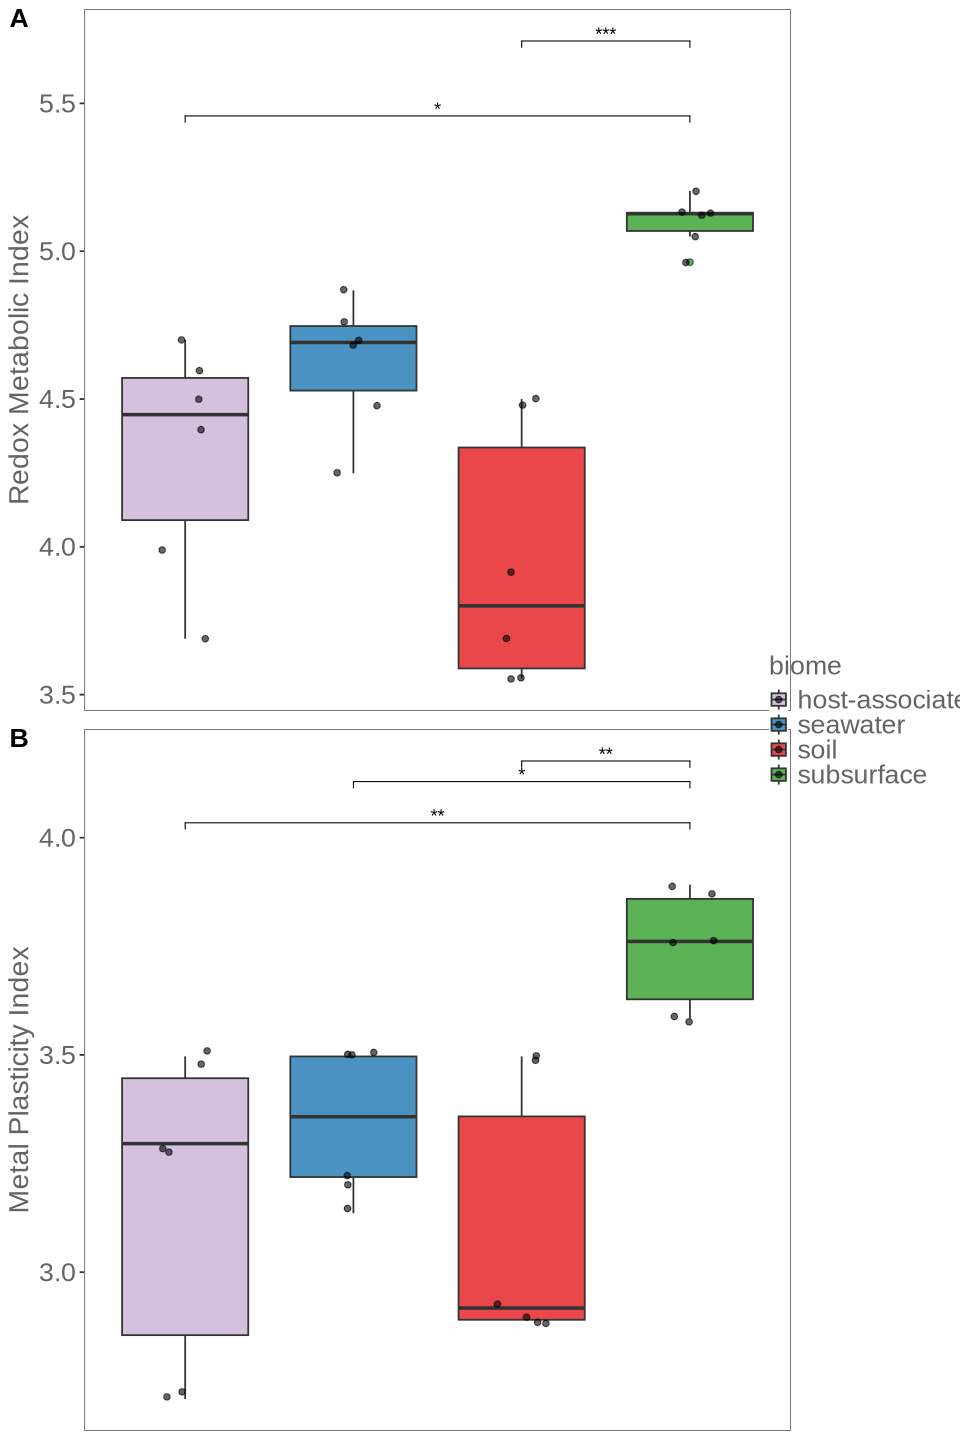

In [23]:
library(cowplot)
library(ggplot2)

biome_colors <- c(
  "#cab2d6",
  "#1F78B4",  # blu
  "#e31a1c",
  "#33a02c"   # verde
)

# --- 4. Boxplot for redox_metabolic_index (RMI) — TOP plot ---
p1 <- ggplot(merged, aes(x = biome, y = redox_metabolic_index, fill = biome)) +
  geom_boxplot(outlier.shape = 21, alpha = 0.8) +
  scale_fill_manual(values = biome_colors) +
  geom_jitter(width = 0.15, size = 1.5, alpha = 0.6) +
  theme_glab() +
  labs(x = NULL, y = "Redox Metabolic Index") +
  stat_pvalue_manual(dunn1, hide.ns = TRUE, label = "p.adj.signif", tip.length = 0.01) +
  theme(
    plot.title       = element_text(size = 17, face = "bold", hjust = 0.5),
    axis.text.x      = element_blank(),    # top plot: no x labels (shared axis with p2)
    axis.ticks.x     = element_blank(),
    axis.text.y      = element_text(size = 16),
    axis.title       = element_text(size = 17),
    strip.text.x     = element_text(size = 16),
    strip.text.y     = element_blank(),
    strip.background = element_blank(),
    legend.position  = "none"              # legend stripped, added back once at the end
  )

# --- 5. Boxplot for metal_plasticity_index (RPI) — BOTTOM plot ---
p2 <- ggplot(merged, aes(x = biome, y = metal_plasticity_index, fill = biome)) +
  geom_boxplot(outlier.shape = 21, alpha = 0.8) +
  scale_fill_manual(values = biome_colors) +
  geom_jitter(width = 0.15, size = 1.5, alpha = 0.6) +
  theme_glab() +
  labs(x = NULL, y = "Metal Plasticity Index") +
  stat_pvalue_manual(dunn2, hide.ns = TRUE, label = "p.adj.signif", tip.length = 0.01) +
 theme(
    plot.title       = element_text(size = 17, face = "bold", hjust = 0.5),
    axis.text.x      = element_blank(),    # top plot: no x labels (shared axis with p2)
    axis.ticks.x     = element_blank(),
    axis.text.y      = element_text(size = 16),
    axis.title       = element_text(size = 17),
    strip.text.x     = element_text(size = 16),
    strip.text.y     = element_blank(),
    strip.background = element_blank(),
    legend.position  = "none"              # legend stripped, added back once at the end
  )

# --- 6. Extract a single shared legend ---
# Build a throwaway copy of p1 just to pull its legend (needs legend.position != "none")
legend <- get_legend(
  p1 + theme(legend.position = "right",
             legend.title    = element_text(size = 16),
             legend.text     = element_text(size = 16))
)

# --- 7. Stack p1 / p2 with aligned axes ---
stacked <- plot_grid(
  p1, p2,
  ncol   = 1,
  align  = "v",     # align vertically so x-axes line up
  axis   = "lr",    # match left/right edges (y-axis label widths differ: "Redox..." vs "Metal...")
  labels = c("A", "B"),
  label_size = 16,
  label_fontface = "bold"
)

# --- 8. Add the shared legend to the right ---
combined_plot <- plot_grid(
  stacked, legend,
  ncol       = 2,
  rel_widths = c(1, 0.2)   # tweak this to control how much space the legend takes
)

combined_plot

# Save
ggsave("../figures/boxplots_redox_metal_tower.svg", combined_plot, width = 8, height = 14, dpi = 300)

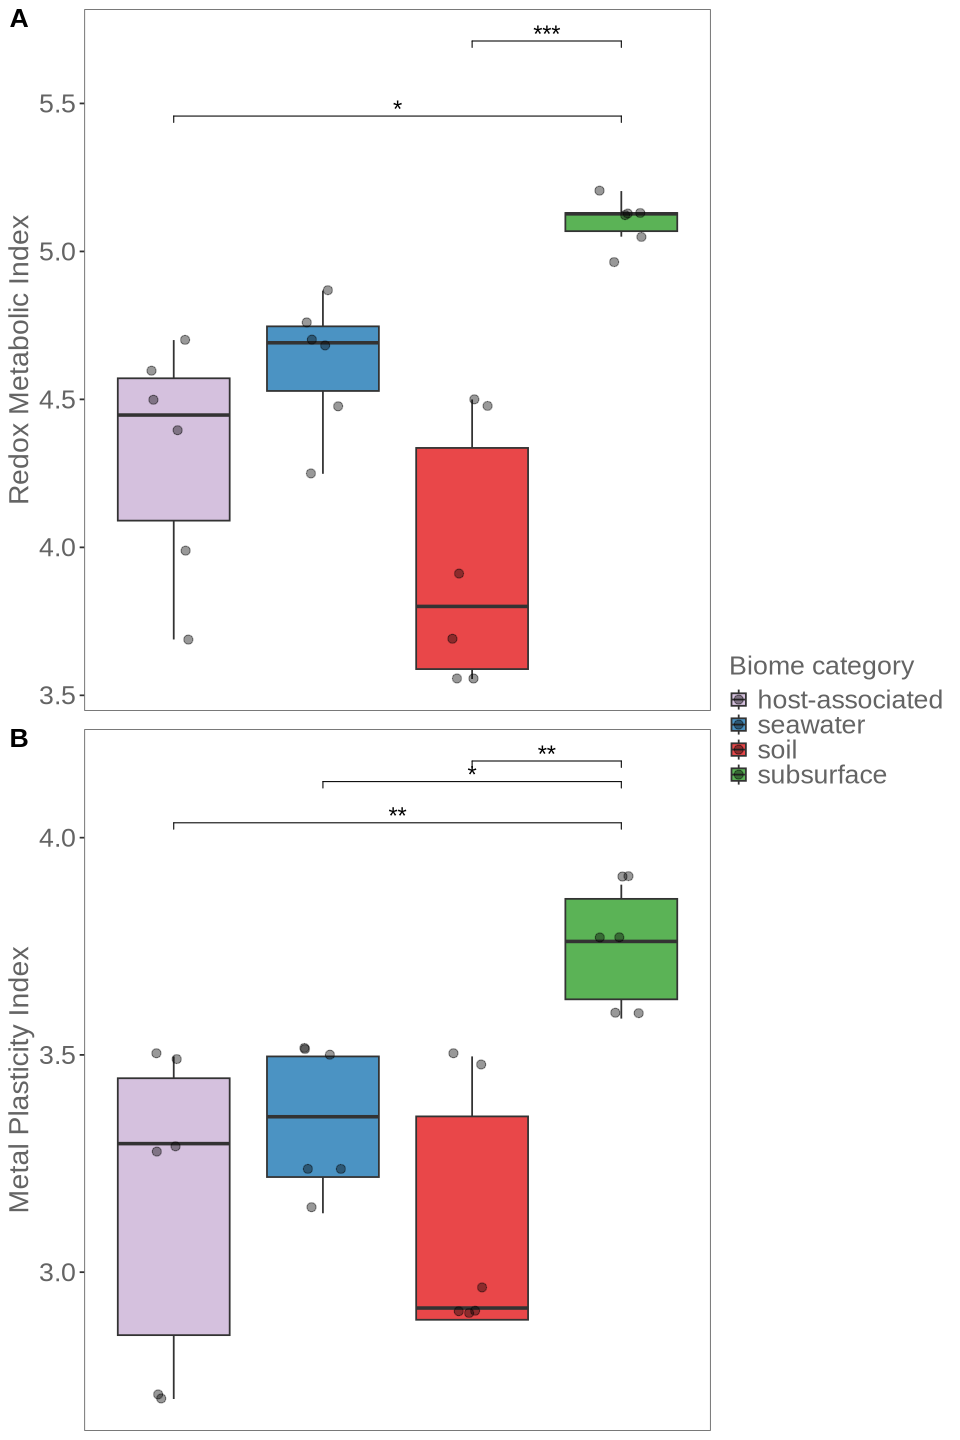

In [32]:
library(ggplot2)
library(ggpubr)

biome_colors <- c(
  "#cab2d6",
  "#1F78B4",  # blue
  "#e31a1c",
  "#33a02c"   # green
)

# --- RMI ---
p1 <- ggplot(
  merged,
  aes(
    x = biome,
    y = redox_metabolic_index,
    fill = biome
  )
) +
  geom_boxplot(
    outlier.shape = NA,   # avoid plotting points twice
    alpha = 0.8
  ) +
  geom_jitter(
    width = 0.15,
    size = 2.2,           # larger points
    alpha = 0.4           # lower alpha
  ) +
  scale_fill_manual(
    values = biome_colors,
    name = "Biome category"
  ) +
  theme_glab() +
  labs(
    x = NULL,
    y = "Redox Metabolic Index"
  ) +
  stat_pvalue_manual(
    dunn1,
    hide.ns = TRUE,
    label = "p.adj.signif",
    tip.length = 0.01,
    label.size = 5         # ← increase this to make asterisks bigger

  ) +
  theme(
    plot.title       = element_text(size = 17, face = "bold", hjust = 0.5),
    axis.text.x      = element_blank(),
    axis.ticks.x     = element_blank(),
    axis.text.y      = element_text(size = 16),
    axis.title       = element_text(size = 17),
    strip.text.x     = element_text(size = 16),
    strip.text.y     = element_blank(),
    strip.background = element_blank(),
    legend.title     = element_text(size = 16),
    legend.text      = element_text(size = 16)
  )


# --- MPI / Metal Plasticity Index ---
p2 <- ggplot(
  merged,
  aes(
    x = biome,
    y = metal_plasticity_index,
    fill = biome
  )
) +
  geom_boxplot(
    outlier.shape = NA,
    alpha = 0.8
  ) +
  geom_jitter(
    width = 0.15,
    size = 2.2,
    alpha = 0.4
  ) +
  scale_fill_manual(
    values = biome_colors,
    name = "Biome category"
  ) +
  theme_glab() +
  labs(
    x = NULL,
    y = "Metal Plasticity Index"
  ) +
  stat_pvalue_manual(
    dunn2,
    hide.ns = TRUE,
    label = "p.adj.signif",
    tip.length = 0.01,
    label.size = 5         # ← increase this to make asterisks bigger

  ) +
  theme(
    plot.title       = element_text(size = 17, face = "bold", hjust = 0.5),
    axis.text.x      = element_blank(),
    axis.ticks.x     = element_blank(),
    axis.text.y      = element_text(size = 16),
    axis.title       = element_text(size = 17),
    strip.text.x     = element_text(size = 16),
    strip.text.y     = element_blank(),
    strip.background = element_blank(),
    legend.title     = element_text(size = 16),
    legend.text      = element_text(size = 16)
  )


# --- Combine with one shared legend ---
combined_plot <- ggarrange(
  p1,
  p2,
  ncol = 1,
  nrow = 2,
  labels = c("A", "B"),
  font.label = list(
    size = 16,
    face = "bold"
  ),
  common.legend = TRUE,
  legend = "right",
  align = "v"
)

combined_plot
ggsave(paste0("../figures/boxplots_redox_metal_tower.png"), combined_plot, width = 8, height = 10, dpi = 300)

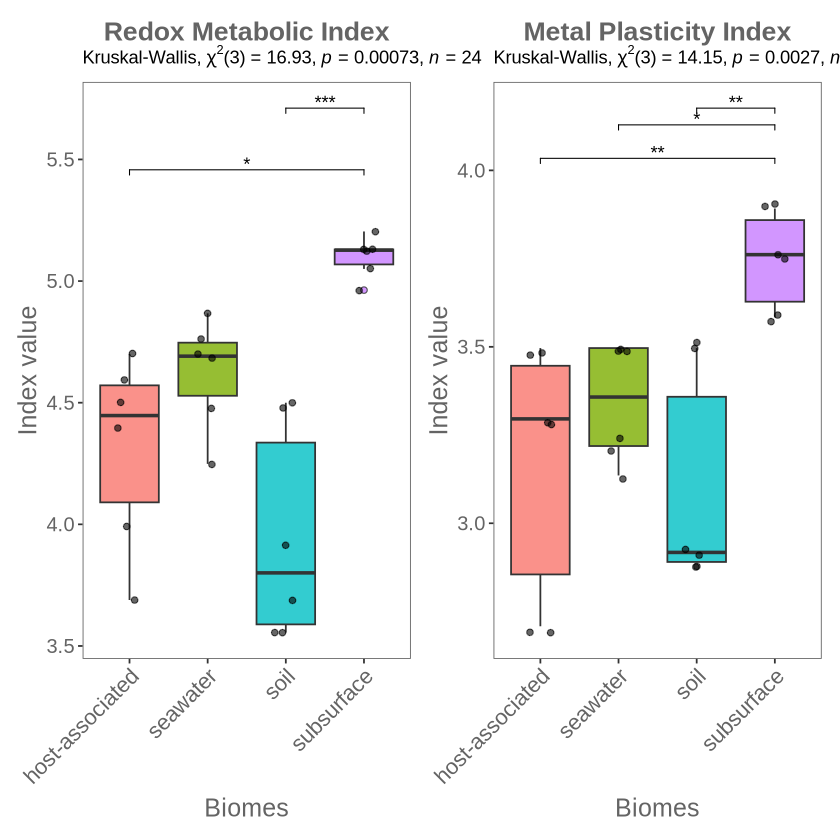

In [ ]:
# --- 4. Boxplot for redox_metabolic_index ---
p1 <- ggplot(merged, aes(x = biome, y = redox_metabolic_index, fill = biome)) +
  geom_boxplot(outlier.shape = 21, alpha = 0.8) +
  geom_jitter(width = 0.15, size = 1.5, alpha = 0.6) +
  theme_glab() +
  labs(title = "Redox Metabolic Index", x = "Biomes", y = "Index value") +
  stat_pvalue_manual(dunn1, hide.ns = TRUE, label = "p.adj.signif", tip.length = 0.01) +
  labs(subtitle = get_test_label(kw1, detailed = TRUE)) +
  theme(
    plot.title        = element_text(size = 16, face = "bold", hjust = 0.5),
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 13),
    axis.text.y       = element_text(size = 12),
    axis.title        = element_text(size = 15),
    strip.text.x      = element_text(size = 12),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 11),
    legend.text       = element_text(size = 10),
    legend.position   = "none"
  )
# --- 5. Boxplot for metal_plasticty_index ---
p2 <- ggplot(merged, aes(x = biome, y = metal_plasticity_index, fill = biome)) +
  geom_boxplot(outlier.shape = 21, alpha = 0.8) +
  geom_jitter(width = 0.15, size = 1.5, alpha = 0.6) +
  theme_glab() +
  labs(title = "Metal Plasticity Index", x = "Biomes", y = "Index value") +
  stat_pvalue_manual(dunn2, hide.ns = TRUE, label = "p.adj.signif", tip.length = 0.01) +
  labs(subtitle = get_test_label(kw2, detailed = TRUE)) +
  theme(
    plot.title        = element_text(size = 16, face = "bold", hjust = 0.5),
    axis.text.x       = element_text(angle = 45, vjust = 1, hjust = 1, size = 13),
    axis.text.y       = element_text(size = 12),
    axis.title        = element_text(size = 15),
    strip.text.x      = element_text(size = 12),
    strip.text.y      = element_blank(),
    strip.background  = element_blank(),
    legend.title      = element_text(size = 11),
    legend.text       = element_text(size = 10),
    legend.position   = "none"
  )
# --- 6. Combine side-by-side ---
combined_plot <- p1 + p2
combined_plot

# Optionally save
ggsave("../figures/boxplots_redox_metal.svg", combined_plot, width = 12, height = 8, dpi = 300)

In [ ]:
kw1

,.y.,n,statistic,df,p,method
,<chr>,<int>,<dbl>,<int>,<dbl>,<chr>
Kruskal-Wallis chi-squared,redox_metabolic_index,24,16.92582,3,0.0007320071,Kruskal-Wallis


In [ ]:
dunn1

.y.                   group1          group2     n1 n2 statistic 
1 redox_metabolic_index host-associated seawater   6  6   0.9606373
2 redox_metabolic_index host-associated soil       6  6  -1.0219546
3 redox_metabolic_index host-associated subsurface 6  6   2.9227901
4 redox_metabolic_index seawater        soil       6  6  -1.9825919
5 redox_metabolic_index seawater        subsurface 6  6   1.9621528
6 redox_metabolic_index soil            subsurface 6  6   3.9447447
  p            p.adj        p.adj.signif y.position groups         
1 3.367346e-01 0.3367345641 ns           5.28848    host-associated
2 3.068024e-01 0.3367345641 ns           5.37296    seawater       
3 3.469103e-03 0.0104073087 *            5.45744    host-associated
4 4.741303e-02 0.0746170467 ns           5.54192    seawater       
5 4.974470e-02 0.0746170467 ns           5.62640    host-associated
6 7.988505e-05 0.0004793103 ***          5.71088    seawater       
  <NA>            <NA>            <NA>     <NA>       <NA>       xmin xmax
1 host-associated host-associated seawater seawater   soil       1    2   
2 soil            subsurface      soil     subsurface subsurface 1    3   
3 host-associated host-associated seawater seawater   soil       1    4   
4 soil            subsurface      soil     subsurface subsurface 2    3   
5 host-associated host-associated seawater seawater   soil       2    4   
6 soil            subsurface      soil     subsurface subsurface 3    4

In [ ]:
dunn2

.y.                    group1          group2     n1 n2 statistic 
1 metal_plasticity_index host-associated seawater   6  6   0.6213524
2 metal_plasticity_index host-associated soil       6  6  -0.2485410
3 metal_plasticity_index host-associated subsurface 6  6   3.1067619
4 metal_plasticity_index seawater        soil       6  6  -0.8698933
5 metal_plasticity_index seawater        subsurface 6  6   2.4854095
6 metal_plasticity_index soil            subsurface 6  6   3.3553029
  p            p.adj       p.adj.signif y.position groups         
1 0.5343677955 0.641241355 ns           3.9394     host-associated
2 0.8037158882 0.803715888 ns           3.9868     seawater       
3 0.0018914867 0.005674460 **           4.0342     host-associated
4 0.3843586984 0.576538048 ns           4.0816     seawater       
5 0.0129402475 0.025880495 *            4.1290     host-associated
6 0.0007927814 0.004756688 **           4.1764     seawater       
  <NA>            <NA>            <NA>     <NA>       <NA>       xmin xmax
1 host-associated host-associated seawater seawater   soil       1    2   
2 soil            subsurface      soil     subsurface subsurface 1    3   
3 host-associated host-associated seawater seawater   soil       1    4   
4 soil            subsurface      soil     subsurface subsurface 2    3   
5 host-associated host-associated seawater seawater   soil       2    4   
6 soil            subsurface      soil     subsurface subsurface 3    4

In [ ]:
kw1

,.y.,n,statistic,df,p,method
,<chr>,<int>,<dbl>,<int>,<dbl>,<chr>
Kruskal-Wallis chi-squared,redox_metabolic_index,24,16.92582,3,0.0007320071,Kruskal-Wallis


In [ ]:
kw2

,.y.,n,statistic,df,p,method
,<chr>,<int>,<dbl>,<int>,<dbl>,<chr>
Kruskal-Wallis chi-squared,metal_plasticity_index,24,14.14593,3,0.002713103,Kruskal-Wallis


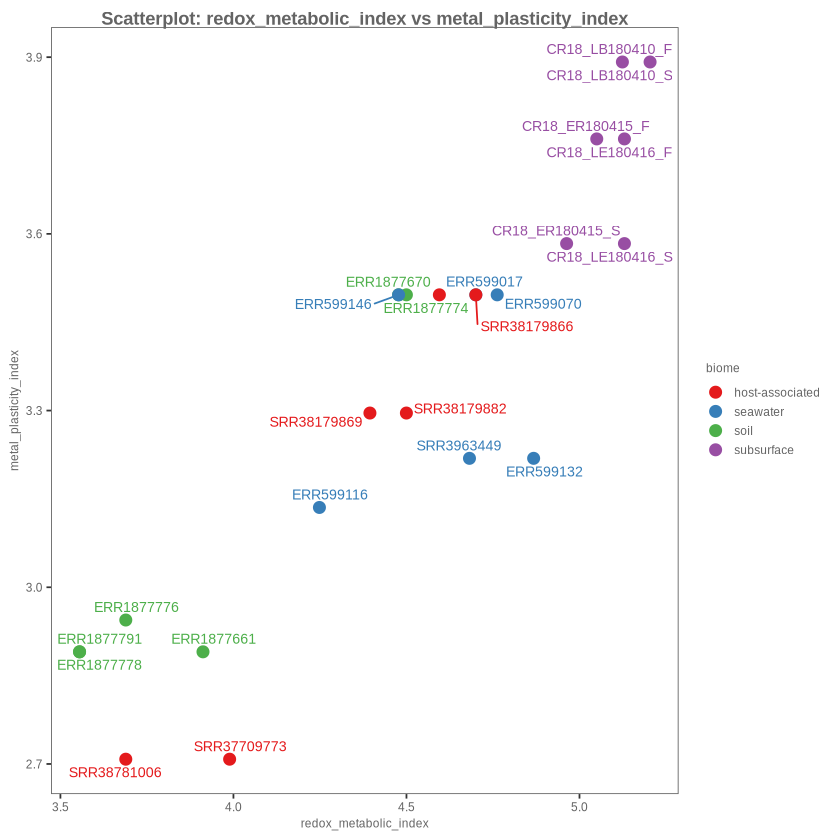

In [ ]:
plot_scatter(merged, "redox_metabolic_index", "metal_plasticity_index","biome","sample")